In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder

### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [27]:
df_drugs = pd.read_csv("data/drugLibTrain_raw.tsv", sep="\t")
df_drugs.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [13]:
df_drugs = df_drugs.rename(columns={"Unnamed: 0": "drug_id"})
df_drugs.head()

,drug_id,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [14]:
df_drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   drug_id            3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [16]:
df_drugs["urlDrugName"].value_counts() 

urlDrugName
lexapro             63
prozac              46
zoloft              45
retin-a             45
propecia            38
                    ..
desonide             1
nasacort-aq          1
glucophage-xr        1
risperdal-consta     1
trileptal            1
Name: count, Length: 502, dtype: int64

In [17]:
df_drugs["effectiveness"].value_counts() 

effectiveness
Highly Effective          1330
Considerably Effective     928
Moderately Effective       415
Ineffective                247
Marginally Effective       187
Name: count, dtype: int64

In [18]:
df_drugs["sideEffects"].value_counts() 

sideEffects
Mild Side Effects                1019
No Side Effects                   930
Moderate Side Effects             614
Severe Side Effects               369
Extremely Severe Side Effects     175
Name: count, dtype: int64

In [19]:
df_drugs["condition"].value_counts() 

condition
depression                    236
acne                          165
anxiety                        63
insomnia                       54
birth control                  49
                             ... 
sleep walking/talking           1
sore throat ear infections      1
nerve disorder                  1
skin cancer                     1
birth prevention                1
Name: count, Length: 1426, dtype: int64

In [20]:
df_drugs["benefitsReview"].value_counts() 

benefitsReview
none                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      20
The treatment benefits were marginal at best.  Mood neither improved nor deteriorated, and anxiety was never significantly alleviated.  Unsurprisingly, recent research suggests that SSRIs are only effective in the most severe of cases.                                                                                                                                                 

In [21]:
df_drugs["sideEffectsReview"].value_counts() 

sideEffectsReview
none                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  112
None.                                                                                                                                                                                                                                       

In [22]:
df_drugs["commentsReview"].value_counts() 

commentsReview
none                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        6
see above                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [28]:
df_drugs_02 = df_drugs[["rating","effectiveness", "sideEffects"]]
df_drugs_02

,rating,effectiveness,sideEffects
0,4,Highly Effective,Mild Side Effects
1,1,Highly Effective,Severe Side Effects
2,10,Highly Effective,No Side Effects
3,3,Marginally Effective,Mild Side Effects
4,2,Marginally Effective,Severe Side Effects
...,...,...,...
3102,10,Highly Effective,Mild Side Effects
3103,1,Ineffective,Extremely Severe Side Effects
3104,2,Marginally Effective,Moderate Side Effects
3105,8,Considerably Effective,Mild Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [34]:
columns_to_encode = ["effectiveness", "sideEffects"]

encoder = OneHotEncoder()
encoder_2 = encoder.fit_transform(df_drugs[columns_to_encode])

df_drugs_encoded = pd.DataFrame(encoder_2.toarray(), columns=encoder.get_feature_names_out(columns_to_encode))

df_drugs_encoded["rating"] = df_drugs_02["rating"]
df_drugs_encoded

,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects,rating
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,10
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
3102,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,10
3103,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3104,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
3105,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

In [35]:
X = df_drugs_encoded
X

,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects,rating
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,10
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
3102,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,10
3103,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
3104,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
3105,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8


In [47]:
K = np.arange(2, 11)

scores = []

for cl in K:
    kmeans = KMeans(n_clusters=cl, random_state=1)
    kmeans.fit(X)

    score = silhouette_score(X, kmeans.labels_)
    print(f"Silhouette score de K = {cl}:", score)
    scores.append(score)

print("_" * 50)
best_index = np.argmax(scores)
best_K = K[best_index]
best_score = scores[best_index]

print(f"K con mejor Silhouette score: {best_K}")

Silhouette score de K = 2: 0.6055089618561077
Silhouette score de K = 3: 0.45301977160140894
Silhouette score de K = 4: 0.39817528676924296
Silhouette score de K = 5: 0.3777149532566565
Silhouette score de K = 6: 0.40254932200442867
Silhouette score de K = 7: 0.4294935012437384
Silhouette score de K = 8: 0.3494121115633311
Silhouette score de K = 9: 0.41569751422918033
Silhouette score de K = 10: 0.4042242554751163
__________________________________________________
K con mejor Silhouette score: 2


#### Genera el K Means 

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [52]:
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(X)

score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette score de K = 2:", score)

pred = kmeans.predict(X)

pred

Silhouette score de K = 2: 0.6055089618561077


array([0, 0, 1, ..., 0, 1, 0], shape=(3107,), dtype=int32)

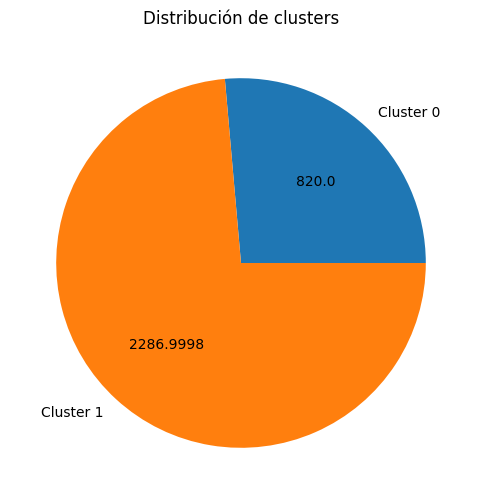

In [64]:
counts = pd.Series(pred).value_counts().sort_index() 

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=[f'Cluster {i}' for i in counts.index],
    autopct=lambda pct: pct*sum(counts)/100
)
plt.title("Distribución de clusters")
plt.show()

### Interpretación de KMeans en nuestro dataset de drogas

1️⃣ **Qué contiene `X`**  

Después de aplicar **OneHotEncoding**, `X` es un DataFrame completamente numérico que incluye:  
- Columnas codificadas de `effectiveness` (`effectiveness_Highly Effective`, etc.)  
- Columnas codificadas de `sideEffects` (`sideEffects_Mild Side Effects`, etc.)  
- La columna `rating`  

Columnas como `drug_id`, `urlDrugName`, `condition`, `benefitsReview`, `sideEffectsReview` y `commentsReview` **no se usan** porque KMeans solo trabaja con valores numéricos.

2️⃣ **Qué hace KMeans**  

KMeans es un algoritmo de clustering que **agrupa las filas del dataset** (cada fila = un medicamento con sus características) en un número fijo de clusters, definido por `n_clusters`. En nuestro caso, usamos 2 clusters.  

El modelo **no está prediciendo** `rating`, `effectiveness` ni `sideEffects`. Lo que hace es analizar las similitudes entre las filas de `X` y asignarlas a clusters de manera automática según estas características.

3️⃣ **Qué significa `pred`**  

El resultado de `kmeans.predict(X)` es un array llamado `pred` que contiene una etiqueta de cluster para cada fila.  

- Cada valor en `pred` es **0 o 1** (porque definimos `n_clusters=2`).  
- Representa **a qué cluster pertenece cada fila**, no un valor real de rating o efectividad.  
- Se trata de un **pseudo-target**, útil para análisis y visualización, pero no es un target verdadero.

4️⃣ **Cómo interpretar los clusters**  

- **Cluster 0** → conjunto de drogas que son similares entre sí según `rating`, `effectiveness` y `sideEffects`.  
- **Cluster 1** → otro conjunto de drogas similares entre sí, pero diferentes al cluster 0.  

Estas etiquetas de cluster **no representan valores reales**, sino la segmentación automática que el modelo ha detectado en los datos.

5️⃣ **Usos de estas etiquetas de cluster**  

- Visualizar la **distribución de clusters**, por ejemplo con un gráfico de pastel o de barras, para ver cuántos medicamentos caen en cada grupo.  
- Analizar **patrones dentro de los clusters**, por ejemplo qué tipos de drogas tienden a agruparse juntas.  
- Comparar los clusters con columnas categóricas reales, como `effectiveness` o `sideEffects`, para ver si los grupos detectados coinciden con categorías conocidas.

✅ **Resumen clave:**  

- KMeans es un modelo **no supervisado**, por lo que **no necesita un target real**.  
- Lo que “predice” son **los clusters asignados a cada fila** basándose en las similitudes de las características.  
- Estas etiquetas son útiles para **visualización, segmentación y análisis de patrones**, pero no corresponden a una variable conocida del dataset.
